# **Lab 2: Predictive Analytics with Machine Learning**


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


**Section 1 — Supervised Learning: Regression**

*Part 1.1 — Load and explore the taxi data*

(41202, 13)
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                      1       

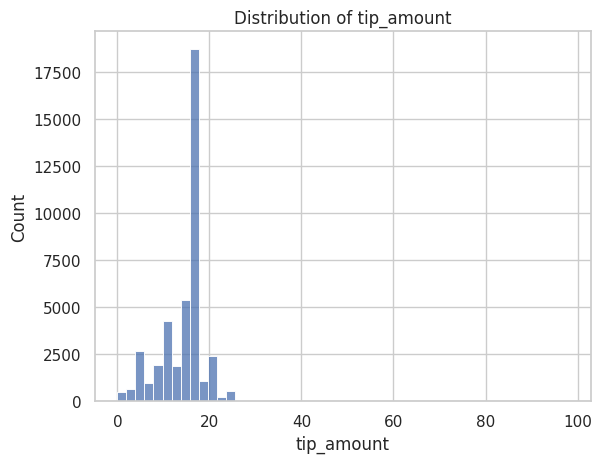

In [2]:
taxi = pd.read_csv(TAXI_URL)

# Inspection
print(taxi.shape)
print(taxi.head())
print("")
taxi.info()
print("")
print(taxi.describe())
print("")
print("missing values per column")
print(taxi.isna().sum())

# Visualisation
sns.histplot(taxi['tip_amount'], bins=50)
plt.title("Distribution of tip_amount")
plt.show()


1.   In each column, there are no missing value, this indicates that the data was already cleaned.

2.   Columns like VendorID, paymentType are not changing; they have constant values. This means that they have zero variance, therefore can not be used in distinguishing one trip from another.

3. Looking at the distribution of tip amount graph, the graph is skewed to the right, and mostly ranges from 0 to approximately 25 with a high concentration between 15 and 17 which matches the median of 16.19;  showing that people often leave a similar tip on trips. Also, the maximum is 98 which shows that there is a presence of outlier.
4. Another observation is that the minimum trip_distance is zero, meaning no trip was made. In preprocessing, these trips will be dropped since the goal is to predict how much of tip from a trip and there is no tip if there is no trip.



*Part 1.2 — Preprocessing & feature engineering*

In [3]:
# Droping rows with invalid values
taxi_clean = taxi[(taxi['trip_distance'] > 0) & (taxi['fare_amount'] > 0)].copy()
print(f"Rows before data cleaning: {taxi.shape[0]}, after data cleaning: {taxi_clean.shape[0]}")

#Droping the zero-variance columns
taxi_clean = taxi_clean.drop(columns=['VendorID', 'payment_type'])

# Feature engineering
taxi_clean['unit_price'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']
taxi_clean['pretip_total'] = (taxi_clean['fare_amount'] + taxi_clean['mta_tax'] + taxi_clean['tolls_amount'] +
                              taxi_clean['improvement_surcharge'])

print(taxi_clean[['unit_price', 'pretip_total']])
print("Any infinite values?", np.isinf(taxi_clean['unit_price']).sum())

# Deciding which columns are categorical and encoding them
taxi_en = pd.get_dummies(taxi_clean, columns=['RatecodeID', 'store_and_fwd_flag'], drop_first=True)
taxi_en = taxi_en.drop(columns=['PULocationID', 'DOLocationID'])
print(taxi_en.shape)
taxi_en.head()


Rows before data cleaning: 41202, after data cleaning: 41126
       unit_price  pretip_total
0        3.970505         78.44
1        3.586066         78.44
2        3.930376         78.44
3        3.626943         71.50
4        3.733333         78.44
...           ...           ...
41197    4.132231         78.44
41198    3.530005         78.44
41199    4.043905         78.44
41200    4.050926         78.44
41201    4.161712         78.44

[41126 rows x 2 columns]
Any infinite values? 0
(41126, 13)


,passenger_count,trip_distance,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,unit_price,pretip_total,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,70.0,0.5,6.94,1,16.54,3.970505,78.44,True,False,False,True
1,1,19.52,70.0,0.5,6.94,1,16.19,3.586066,78.44,True,False,False,True
2,1,17.81,70.0,0.5,6.94,1,12.00,3.930376,78.44,True,False,False,True
3,2,19.30,70.0,0.5,0.00,1,5.00,3.626943,71.50,True,False,False,True
4,1,18.75,70.0,0.5,6.94,1,10.00,3.733333,78.44,True,False,False,True




1.   I dropped the rows with invalid and unneeded values because zero or negative distance/fare are not valid trips and would distort the relationship between trip characteristics and tip amount.

2.   I dropped the zero variancecolumns (VendorID, payment_type) since they they do not help in distinguishing tipping in one trip and another and no they have no information a model can learn from.

3. I also dropped PULocationID and DOLocationID  since one-hot encoding them would have caused noise data

4. For feature engineering, I choose fare per mile(unit price) and the total fare amount before tipping because most people tip based on how much they are going to pay and whether they think the price is fair based on the distance they travelled and pretip_total specifically represents what the rider sees on the payment screen before deciding a tip.



*Part 1.3 — Train / Validation / Test split*

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#separating features and target
X = taxi_en.drop(columns=['tip_amount'])
y = taxi_en['tip_amount']

#splitting and scanning
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1875, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: (26731, 12), Val: (6169, 12), Test: (8226, 12)




1.   I used a 65/15/20 split ratio, meaning 65% of the data is used for training, 15% for validation, and 20% for testing. I chose this because with roughly  over 41,000 rows, even 15-20% still gives thousands of rows in validation and test, which is enough for reliable, stable evaluation metrics, while keeping the majority of the data (65%) available for the model to learn from.

2.   The test set is only used once, at the very end, to give an honest final evaluation of the model while validation is used during learning process.The purpose of a validation set is to allow trial-and-error during model development through comparing different models, features, or hyperparameters without touching the test data set. So, if we used the test set for this repeated learning process instead, it would indirectly shape the model to perform well specifically on those test rows, making the test score too good rather than a true measure of how the model actually performs on unseen data.

3. The scaler must be fit on the training data only because fitting it calculates its statistics. If the scaler were fit on the combined train, validation, and test data, those statistics would be influence the model's prediction because the training data would indirectly be transformed using information it should not have access to yet. This is a form of data leakage: even though tip_amount isn't involved, the test set is meant to potray new, unseen data, and if its distribution has already influenced preprocessing, the final test evaluation would no longer be an honest measure of how the model performs on truly new data. It is better fitting the scaler on training data only, then applying that same transformation to validation and test, keeps the evaluation honest.



*Part 1.4 — Train a regressor and check for overfitting*

Linear regression
Train:  (4.8338, 3.5714, 0.0507)
Validation:  (4.9927, 3.5616, 0.0496)
Test:  (5.0143, 3.5884, 0.0506)

Decision tree regressor
Train:  (4.1049, 2.8044, 0.3154)
Validation:  (5.6634, 3.8838, -0.2229)
Test:  (5.8067, 3.9251, -0.2731)


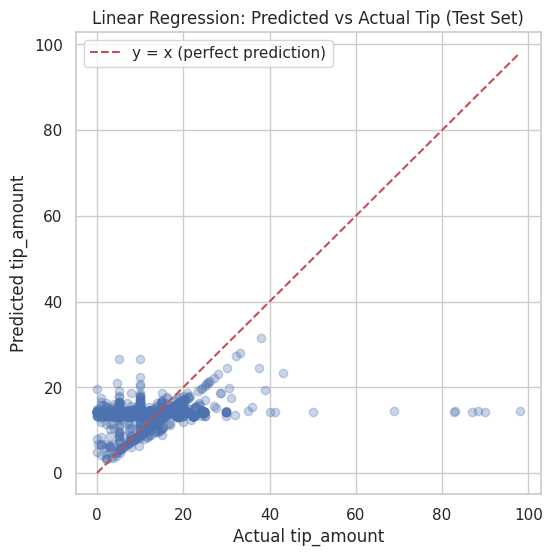

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(model, X, y):
    preds = model.predict(X)
    rmse = float(np.sqrt(mean_squared_error(y, preds)))
    mae = float(mean_absolute_error(y, preds))
    r2 = float(r2_score(y, preds))
    return round(rmse, 4), round(mae, 4), round(r2, 4)

# Linear regression
print("Linear regression")
lin_reg = LinearRegression().fit(X_train_scaled, y_train)
print("Train: ", evaluate(lin_reg, X_train_scaled, y_train))
print("Validation: ", evaluate(lin_reg, X_val_scaled, y_val))
print("Test: ", evaluate(lin_reg, X_test_scaled, y_test))

# Decision tree regressor
print("")
print("Decision tree regressor")
tree_reg = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
print("Train: ", evaluate(tree_reg, X_train_scaled, y_train))
print("Validation: ", evaluate(tree_reg, X_val_scaled, y_val))
print("Test: ", evaluate(tree_reg, X_test_scaled, y_test))


# Plotting to compare Predicted vs Actual Tip
lin_preds_test = lin_reg.predict(X_test_scaled)
plt.figure(figsize=(6,6))
plt.scatter(y_test, lin_preds_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='y = x (perfect prediction)')
plt.xlabel('Actual tip_amount')
plt.ylabel('Predicted tip_amount')
plt.title('Linear Regression: Predicted vs Actual Tip (Test Set)')
plt.legend()
plt.show()



1.   In validation, linear regression has R² = 0.0485 and Decision Tree has R² = -0.1885; this shows that linear regression performed better than Decision Tree. Neither model was tuned.

2.   Linear regression is underfitting while decision tree is overfitting. Linear Regression's R² stayed almost the same across train (0.0512), validation (0.0485), and test (0.0510); it's underfitting, the model is not learning much because 5% is being predicted but 95% the model is guessing. The Decision Tree scored 0.3275 on train but dropped to -0.1885 on validation and -0.2953 on test, which is a big gap and means it's overfitting, it memorized the training data but did not learn.

3.   To fix the Decision Tree's overfitting, I would limit its depth so it can't split down to small, overly specific groups of training rows.

The plot shows the predictions are mostly squeezed around 10-15, no matter what the actual tip was. It follows the actual tips for smaller trips, but for the big tips like 40, 70, or 98, the model still predicts around 14-15, showing it didn't really learn what causes a bigger tip. This matches the low R² score we got earlier.



**Section 2 — Supervised Learning: Multi-class Classification**


*Part 2.1 — Load and explore the obesity data*

(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportat

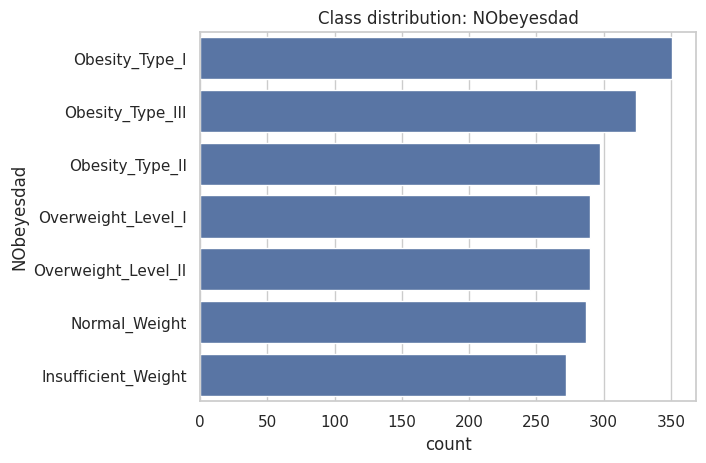

In [6]:
obesity = pd.read_csv(OBESITY_URL)

print(obesity.shape)
print(obesity.head())
obesity.info()
print(obesity.describe())
print(obesity.isna().sum())
print(obesity['NObeyesdad'].value_counts())
sns.countplot(data=obesity, y='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.title('Class distribution: NObeyesdad')
plt.show()



1.   There are 2111 rows and 17 columns (features). There is no missing data, which suggests that the data might have already been cleaned.

2.   There are 9 categorical features and 8 numerical features.

3. The class counts range from 272 to 351, which indicates the target classes are roughly balanced across all 7 categories rather than skewed toward one or two.

4. Class balance matters because classification algorithms aim to minimize overall error, so if one class were much rarer than others, the model would ignore it and still scoring well overall so balanced classes reduce that risk.

*Part 2.2 — Preprocessing & feature engineering*

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical columns
obesity_enc = obesity.copy()
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity_enc[col] = obesity_enc[col].map({'yes': 1, 'no': 0})

obesity_enc = pd.get_dummies(obesity_enc, columns=['Gender', 'MTRANS'], drop_first=True)

# Ordinal-ish columns -> ordinal encoding (there's a natural low-to-high order)
order = ['no', 'Sometimes', 'Frequently', 'Always']
for col in ['CAEC', 'CALC']:
    obesity_enc[col] = obesity_enc[col].map({v: i for i, v in enumerate(order)})

# BMI feature
obesity_enc['BMI'] = obesity_enc['Weight'] / (obesity_enc['Height'] ** 2)
obesity_enc = obesity_enc.drop(columns=['BMI'])

# Scaling the numeric features
le = LabelEncoder()
obesity_enc['NObeyesdad_encoded'] = le.fit_transform(obesity_enc['NObeyesdad'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}




1.   Binary columns (family_history_with_overweight, FAVC, SMOKE, SCC) were mapped to 0 and 1 because they only have two possible values, so a single number can represent them without implying any order.

2.   CAEC and CALC (no/Sometimes/Frequently/Always) were mapped to numbers 0-3, because they represent a natural increasing frequency, and encoding them as ordered numbers preserves that relationship, which one-hot encoding would have thrown away.

3. Gender and MTRANS were one-hot encoded instead of mapped to numbers, because they have no natural order, so assigning them arbitrary numbers would falsely imply that one category is "more" or "less" than another.

4. I engineered a BMI feature but dropped it before training, because it is almost equivalent to the target; obesity categories are medically defined by BMI, so including it would let the model achieve high accuracy which is not from learning genuine patterns.

*Part 2.3 — Stratified Train / Validation / Test split*

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Splitting
X = obesity_enc.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y = obesity_enc['NObeyesdad_encoded']

X_temp, X_test_o, y_temp, y_test_o = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train_o, X_val_o, y_train_o, y_val_o = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)
print(X_train_o.shape, X_val_o.shape, X_test_o.shape)

# Fitting the scaler on the training set and transforming train / val / test
scaler2 = StandardScaler()
X_train_o_scaled = scaler2.fit_transform(X_train_o)
X_val_o_scaled = scaler2.transform(X_val_o)
X_test_o_scaled = scaler2.transform(X_test_o)

print("Full dataset:\n", y.value_counts(normalize=True).sort_index())
print("\nTrain:\n", y_train_o.value_counts(normalize=True).sort_index())

(1266, 19) (422, 19) (423, 19)
Full dataset:
 NObeyesdad_encoded
0    0.128849
1    0.135955
2    0.166272
3    0.140692
4    0.153482
5    0.137376
6    0.137376
Name: proportion, dtype: float64

Train:
 NObeyesdad_encoded
0    0.128752
1    0.135861
2    0.166667
3    0.140600
4    0.153239
5    0.137441
6    0.137441
Name: proportion, dtype: float64




1.   I used a 60/20/20 split with stratify=y passed to both train_test_split calls; meaning 60% of the data is used for training, 20% for validation, and 20% for testing. I chose this because with 2,111 rows, even 20% still gives thousands of rows in validation and test, which is enough for reliable, stable evaluation metrics, while keeping the majority of the data available for the model to learn from.

2.   Stratification matters because without it, a random split could by chance put more of one class into train and less into test which could distort both what the model learns and how reliable the evaluation is.

3. When we compare class proportions between the full dataset and the train set, the result confirms that stratification worked  and every class proportion matches, for example, class 0 is 12.88% in both, class 2 is 16.63% in full and 16.67% in train. This means each split is a fair, representative sample of the whole dataset.



*Part 2.4 — Train a classifier and check for overfitting*

Train Acc: 0.9013 F1: 0.8982
Val Acc: 0.8555 F1: 0.8477
Test Acc: 0.8558 F1: 0.8498


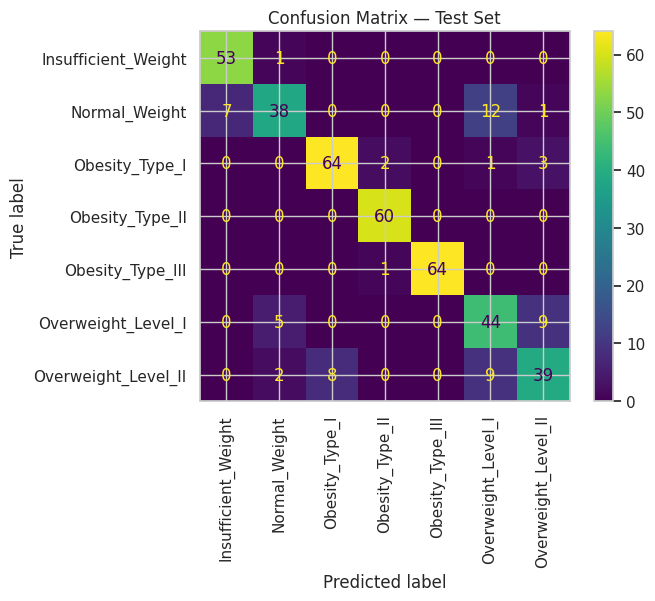

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Import, initialise, and train a classifier
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_o_scaled, y_train_o)

# Predict on train, validation, and test and Report accuracy AND macro-F1 for ALL THREE sets
for name, X, y in [("Train", X_train_o_scaled, y_train_o), ("Val", X_val_o_scaled, y_val_o), ("Test", X_test_o_scaled, y_test_o)]:
    preds = clf.predict(X)
    print(name, "Acc:", round(accuracy_score(y, preds), 4), "F1:", round(f1_score(y, preds, average='macro'), 4))

# Show a confusion matrix for the test set
test_preds = clf.predict(X_test_o_scaled)
ConfusionMatrixDisplay.from_predictions(y_test_o, test_preds, display_labels=le.classes_, xticks_rotation=90)
plt.title("Confusion Matrix — Test Set")
plt.show()



1.   I chose Logistic Regression because it's a simple and easy to interpret for multi-class classification. Since the remaining features relate strongly to obesity category a linear model is more fit than a complex model.

2.  Accuracy was 0.9013 on train, 0.8555 on validation, and 0.8558 on test, with macro-F1 following a similar pattern (0.8982, 0.8477, 0.8498). The gap between train and validation/test is small and validation and test scores are close to each other, so the model is well-fitted.

3. Adjacent severity levels are hardest to tell apart, for example, Overweight_Level_I and Overweight_Level_II were confused with each other (8 and 7 misclassifications), and Normal_Weight was sometimes predicted as Overweight_Level_I (10 misclassifications). This likely happens because these categories are next to each other on the obesity severity scale, so people near the boundary between two adjacent categories can have very similar weight, height, and lifestyle values, making them genuinely hard to distinguish. In contrast, distant classes, for example Insufficient_Weight vs Obesity_Type_III, are almost never confused, since their feature values are much more different.



**Section 3 — Unsupervised Learning: K-Means Clustering**

*Part 3.1 — Choose k, fit K-Means, and visualise*

(2111, 19)


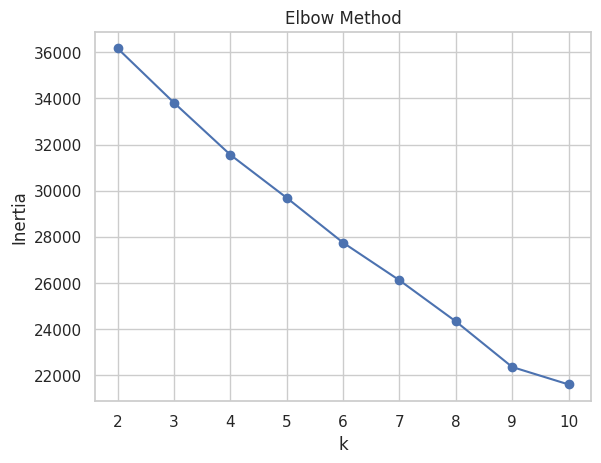

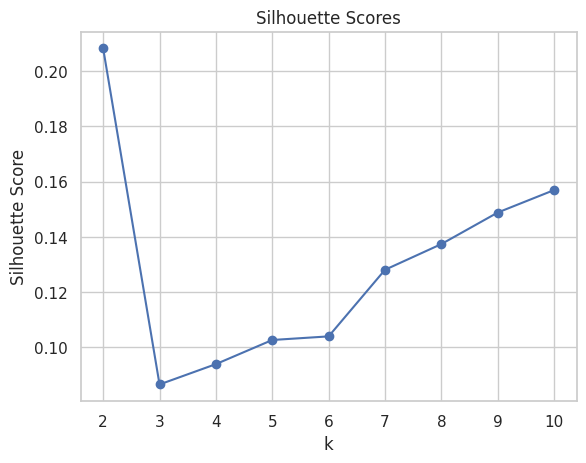

NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
row_0                                                            
0                           125            100               4   
1                             0              1               7   
2                             0             17             105   
3                            47             61             102   
4                             6             32               2   
5                            21             25               2   
6                             0              6               3   
7                            73             41             126   
8                             0              4               0   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
row_0                                                               
0                         1                 0                  45   
1                         0               322                   8 

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = obesity_enc.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
print(X.shape)

X_all_scaled = scaler2.transform(X)

inertias, sil_scores = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_all_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_all_scaled, km.labels_))

plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.show()

plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette Score'); plt.title('Silhouette Scores')
plt.show()

k_chosen = 9 # Using elbow method
kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10).fit(X_all_scaled)
cluster_labels = kmeans.labels_
crosstab = pd.crosstab(cluster_labels, obesity['NObeyesdad'])
print(crosstab)

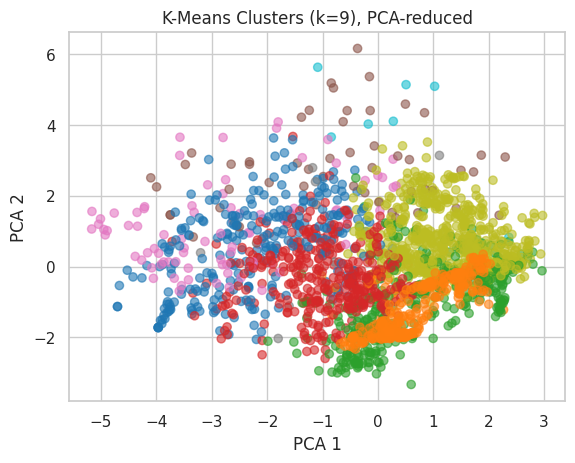

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_all_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='tab10', alpha=0.6)
plt.xlabel('PCA 1'); plt.ylabel('PCA 2'); plt.title(f'K-Means Clusters (k={k_chosen}), PCA-reduced')
plt.show()



1.   The elbow and silhouette methods disagreed. The elbow plot showed a smooth decline with no sharp bend, but the drop from k=9 to k=10 , suggesting the elbow flattens around k=9. The silhouette score, however, was highest at k=2 and much lower at k=9. I chose to prioritize the elbow's k=9, even though this meant accepting lower cluster separation.

2.   With k=9, the clusters do not map cleanly onto the 7 real obesity categories, except for one: cluster 1 is almost entirely Obesity_Type_III. The rest are messly scattered. This lines up with the low silhouette score and the heavy overlap visible in the PCA plot: k=9 finds more granular splits, but most of them don't correspond to meaningful, well-separated groups.

3. Since clustering doesn't require labeled data, these clusters could be used to quickly group people into  emergency groups without needing a doctor or clinician to formally diagnose each person's obesity category first. This could help public health programs proitize those with high-risk patients. However, the messier clusters would be less useful for targeting, since they mix people across very different weight categories.


**Section 4 — Reflection**



1.   Supervised vs unsupervised: The classifier learned to map specific input features directly to the 7 known obesity labels, using those labels during training to correct its predictions. K-Means had no access to labels at all — it could only group people based on how similar their feature values were to each other. Even when forced to find 9 clusters (matching or exceeding the number of real categories), K-Means only cleanly isolated one true category (Obesity_Type_III), while the rest of the clusters mixed multiple real categories together. This shows that clustering finds groupings based on overall feature similarity, not the specific medical thresholds used to define obesity levels.

2.    Regression vs classification: In evaluating the taxi tip regression model, we were looking at how close numeric predictions were to the actual continuous tip amount, using metrics like RMSE, MAE, and R² to measure the size of the prediction error. While in evaluating the obesity classifier meant checking whether predictions matched the correct discrete category, using accuracy, F1-score, and a confusion matrix to see which specific classes were being confused with each other. So, regression cares about the difference in number while classification cares about whether the right category was chosen or not, and if not, which wrong category it was mistaken for.

3. Overfitting: The biggest train-vs-test gap by far was in Section 1's Decision Tree Regressor. On the training set it scored R² = 0.3275, but that collapsed to R² = -0.1885 on validation and R² = -0.2953 on test and negative R² means the model is doing worse than just predicting the mean tip every time, so it had essentially memorized the training rows rather than learning a general pattern. This is a much bigger gap than in Section 2 or Section 3, where K-Means doesn't have a train/test split to begin with since it never sees labels. The single most effective fix for the Decision Tree would be to limit its depth.

